In [1]:
import torch

In [2]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy import special as sc
from torch.autograd import Variable


# Define the desired types
rtype = torch.float32
ctype = torch.complex64

# Create tensors with single precision
t0 = torch.tensor(0.0, dtype=rtype)           # initial time
t1 = torch.tensor(np.pi, dtype=rtype)        # final time
xl = torch.tensor(0.0, dtype=rtype)           # left domain boundary
xr = torch.tensor(8.0, dtype=rtype)           # right domain boundary
hbar = torch.tensor(1.0, dtype=rtype)         # physical constant
mass = torch.tensor(1.0, dtype=rtype)         # physical constant

# Cast to complex type if needed
chbar = hbar.to(ctype)
cmass = mass.to(ctype)


# define plane wave
def psi(x, t):
    return sine_wave(x, t)

# Plane wave function
def plane_wave(x, t):
    k = 1.0
    omega = 0.5 / mass * k**2
    re = torch.cos(k * x - omega * t)
    im = torch.sin(k * x - omega * t)
    return torch.stack([re, im], dim=-1)

# Gaussian wave packet
def gaussian(x, t):
    xc = 0.5          # center of wave packet
    alpha = 0.01      # width of wave packet
    cx = x.to(ctype)
    ct = t.to(ctype)
    psi = torch.sqrt(1 / (alpha + 1j * ct * chbar / cmass)) * torch.exp(
        -((cx - xc) ** 2) / (2 * (alpha + 1j * ct * chbar / cmass))
    )
    return torch.cat([torch.real(psi), torch.imag(psi)], dim=-1)

# Moving Gaussian wave packet
def moving_gaussian(x, t):
    xc = torch.tensor(0.5, dtype=ctype)           # center of wave packet
    alpha = torch.tensor(1.0 / 100, dtype=ctype)   # width of wave packet
    k = 1.0
    s = 0.1
    cx = x.to(ctype)
    ct = t.to(ctype)
    s2 = s**2
    psi = torch.exp(-0.25 * (cx - xc - 2j * k * s2)**2 / (s2 + 1j * ct))
    psi *= torch.exp(1j * k * xc - k**2 * s2) / torch.sqrt(s2 + 1j * ct)
    psi *= (0.5 * s2 / np.pi)**0.25
    return torch.stack([torch.real(psi), torch.imag(psi)], dim=-1)

# Li2 wave function using Fresnel integrals
# def li2(x, t, A=torch.sqrt(5) - torch.sqrt(6), B=torch.sqrt(6)):
#     x0 = 0  # You may need to define x0 if it’s not provided elsewhere
#     C, S = sc.fresnel((x - x0) * torch.sqrt(1 / (np.pi * t * hbar / mass)))
#     psi = A / 2 + B - A / 2 * (1 + 1j) * C - A / 2 * (1 - 1j) * S
#     return psi

# Initial Periodic Sine Wave function
def sine_wave(x, t):
    re = (1.0 + 0.6 * torch.sin(np.pi * x / 4)) ** 0.5
    im = torch.zeros_like(x)
    return torch.cat([re, im], dim=1)

# Density and real/imaginary part functions
def get_density(psi):
    return torch.square(psi[:, 0]) + torch.square(psi[:, 1])

def get_real(psi):
    return psi[:, 0]

def get_imag(psi):
    return psi[:, 1]




# Parameters for sampling
n_initial = 10000
n_boundary = 10000
n_collocation = 20000

# Draw initial data at t0 from uniform distribution
t_initial = Variable(torch.ones((n_initial, 1), dtype=rtype) * t0,requires_grad = False)
x_initial = Variable(torch.rand((n_initial, 1), dtype=rtype) * (xr - xl) + xl,requires_grad = False)
xt_initial = torch.cat([x_initial, t_initial], dim=1)
psi_initial = psi(x_initial, t_initial)
psi_re_0 = Variable(get_real(psi_initial),requires_grad = False)
psi_im_0 = Variable(get_imag(psi_initial),requires_grad = False)

# Draw boundary data from uniform distributions for t and x
t_boundary = Variable(torch.rand((n_boundary, 1), dtype=rtype) * (t1 - t0) + t0,requires_grad = False)

# Map to left and right boundary via a Bernoulli distribution
boundary_choice = torch.bernoulli(torch.rand((n_boundary, 1)))
x_boundary = xl + (xr - xl) * boundary_choice
xt_boundary = torch.cat([x_boundary, t_boundary], dim=1)
psi_boundary = psi(x_boundary, t_boundary)

xl_boundary = Variable(torch.ones((n_boundary,1),dtype = rtype)*xl,requires_grad=True)
xlt_boundary = Variable(torch.cat([xl_boundary,t_boundary],axis = 1),requires_grad = True)
xr_boundary = Variable(torch.ones((n_boundary,1),dtype = rtype)*xr,requires_grad = True)
xrt_boundary = Variable(torch.cat([xr_boundary,t_boundary],axis = 1),requires_grad = True)


# Draw collocation points from uniform distribution
t_collocation = Variable(torch.rand((n_collocation, 1), dtype=rtype) * (t1 - t0) + t0,requires_grad=True)
x_collocation = Variable(torch.rand((n_collocation, 1), dtype=rtype) * (xr - xl) + xl,requires_grad= True)
xt_collocation = Variable(torch.cat([x_collocation, t_collocation], dim=1),requires_grad = True)


In [3]:


class Sin(nn.Module):
    def forward(self, input):
        return torch.sin(input)
class Sin_s(nn.Module):
    def forward(self, input):
        return input*torch.sin(input)

class PINNs(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_layer):
        super(PINNs, self).__init__()


        layers = []
        for i in range(num_layer-1):
            if i == 0:
                layers.append(nn.Linear(in_features=in_dim, out_features=hidden_dim))
                layers.append(Sin())
                # layers.append(torch.sin(layers))
            else:
                layers.append(nn.Linear(in_features=hidden_dim, out_features=hidden_dim))
                layers.append(Sin())

        layers.append(nn.Linear(in_features=hidden_dim, out_features=out_dim))
        #layers.append(Sin_s())#nn.SiLU())

        self.linear = nn.Sequential(*layers)

    def forward(self, x, t):
        src = torch.cat((x,t), dim=-1)
        return self.linear(src)


def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)

net = PINNs(in_dim=2, hidden_dim=32, out_dim=3, num_layer=3)
net.apply(init_weights) ## This is optional
print(net)

PINNs(
  (linear): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Sin()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Sin()
    (4): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [4]:
net.load_state_dict(torch.load('PINN_correct2.pt'))

/var/folders/1z/7szzkg216zx__vgx8p4vkt_h0000gp/T/ipykernel_1301/1798528142.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load('PINN_correct2.

<All keys matched successfully>

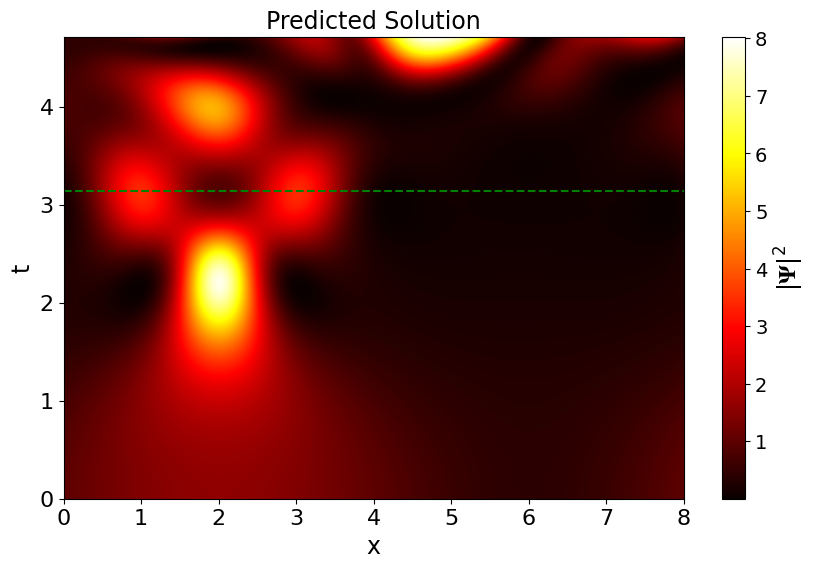

In [13]:
# Define spatial (x) and temporal (t) ranges
x_min, x_max, x_points = 0.0, 8.0, 1000  # Spatial range and resolution
t_min, t_max, t_points = 0, 1.5*np.pi, 1000    # Temporal range and resolution

# Generate x and t values
x_vals = torch.linspace(x_min, x_max, x_points).view(-1, 1)  # Shape: (x_points, 1)
t_vals = torch.linspace(t_min, t_max, t_points).view(-1, 1)  # Shape: (t_points, 1)

# Initialize a 2D array to store density values
density_map = np.zeros((t_points, x_points))

# Loop over time steps to compute density
for i, t in enumerate(t_vals):
    t_1 = torch.ones_like(x_vals) * t  # Shape: (x_points, 1)
    xt_1 = torch.cat([x_vals, t_1], dim=1)  # Combine x and t into (x, t) pairs
    
    # Predict density at the current time step
    psi_collocation_pred = net(x_vals, t_1)[:, 0:2]  # Assuming net outputs real and imaginary parts
    density_pred = get_density(psi_collocation_pred)  # Compute density (shape: (x_points, 1))
    
    # Store density in the 2D array
    density_map[i, :] = density_pred.detach().cpu().numpy().flatten()

# Plot the density using imshow
plt.figure(figsize=(10, 6))
extent = [x_min, x_max, t_min, t_max]  # Define axis limits for imshow
plt.imshow(density_map, extent=extent, origin='lower', aspect='auto',cmap = 'hot')#, cmap='viridis')
plt.plot(x_vals, np.pi*torch.ones_like(x_vals), linestyle = '--',color = 'green')
#plt.colorbar(label='$|\U0001D6BF|^2$')#Density',size = 15)
cbar = plt.colorbar(label='$|\U0001D6BF|^2$')
cbar.set_label('$|\U0001D6BF|^2$', fontsize=17)
cbar.ax.tick_params(labelsize=14)  # Adjust tick size here

plt.xlabel('x',size = 17)
plt.ylabel('t',size = 17)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
##plt.title('Density Visualization (Predicted by Neural Network)')
plt.title('Predicted Solution',size = 17)3
plt.show()

In [40]:
v_collocation_pred = 1/(get_density(psi_collocation_pred)) * (psi_collocation_pred[:,0]*torch.autograd.grad(psi_collocation_pred[:,1],x_1,grad_outputs=torch.ones_like(psi_collocation_pred[:,1]), create_graph=True)[0].flatten()-
                                                              psi_collocation_pred[:,1]*torch.autograd.grad(psi_collocation_pred[:,0],x_1,grad_outputs=torch.ones_like(psi_collocation_pred[:,0]), create_graph=True)[0].flatten())

In [15]:
torch.autograd.grad(psi_collocation_pred[:,1],x_1,grad_outputs=torch.ones_like(psi_collocation_pred[:,1]), create_graph=True)[0].shape

torch.Size([10000, 1])

In [ ]:
time_indices = [i / 100 for i in range(0,314, 15)]  # Time points to visualize
dat1 = [i.detach().numpy() for i in dat]#np.arange(0,len(dat1))
colors = np.random.rand(len(time_indices), 3)  # RGB values
sc = plt.scatter(time_indices,dat1, s=100, edgecolor='k', alpha=0.7)
plt.plot(time_indices,np.ones(21), linestyle = '--',color = 'black')
#plt.title('Mass Conservation (Normalization)')
#plt.colorbar(sc)
plt.xlabel('Time (t)',size = 15)
plt.ylabel(r"$\frac{1}{L} \int |\Psi|^2 dx$",size = 15)

# Set log scale for y-axis
#plt.yscale('logit')
plt.ticklabel_format(axis = 'y', style = 'scientific')


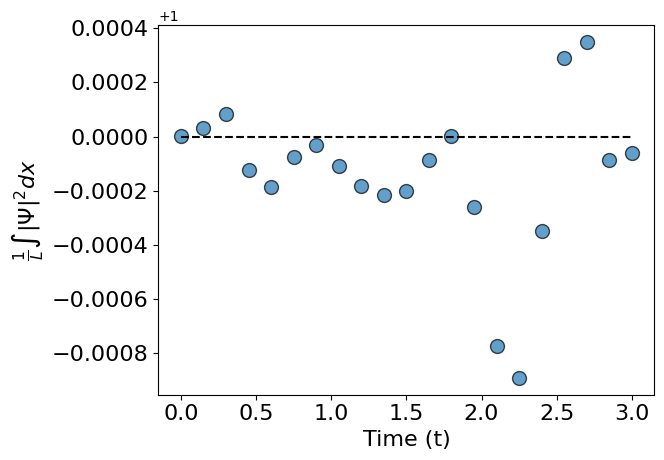

In [27]:
time_indices = [i / 100 for i in range(0,314, 15)]  # Time points to visualize
dat1 = [i.detach().numpy() for i in dat]#np.arange(0,len(dat1))
colors = np.random.rand(len(time_indices), 3)  # RGB values
sc = plt.scatter(time_indices,dat1, s=100, edgecolor='k', alpha=0.7)
plt.plot(time_indices,np.ones(21), linestyle = '--',color = 'black')
#plt.title('Mass Conservation (Normalization)')
#plt.colorbar(sc)
plt.xlabel('Time (t)',size = 16)
plt.ylabel(r"$\frac{1}{L} \int |\Psi|^2 dx$",size = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
# Set log scale for y-axis
#plt.yscale('logit')
plt.ticklabel_format(axis = 'y', style = 'scientific')


Text(0, 0.5, '$\\psi$ integrated over x')

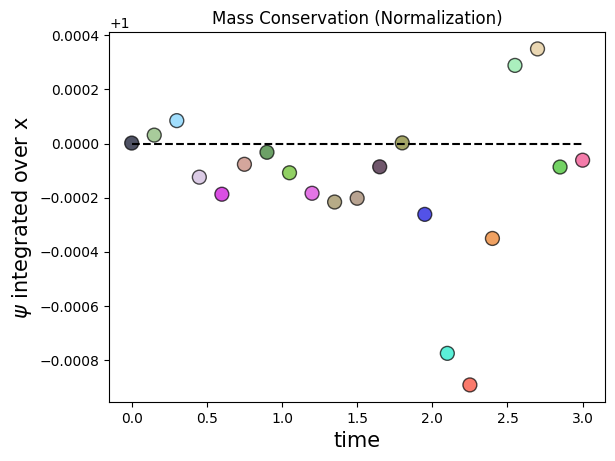

In [32]:
time_indices = [i / 100 for i in range(0,314, 15)]  # Time points to visualize
dat1 = [i.detach().numpy() for i in dat]#np.arange(0,len(dat1))
colors = np.random.rand(len(time_indices), 3)  # RGB values
sc = plt.scatter(time_indices,dat1, c= colors, s=100, edgecolor='k', alpha=0.7)
plt.plot(time_indices,np.ones(21), linestyle = '--',color = 'black')
plt.title('Mass Conservation (Normalization)')
#plt.colorbar(sc)
plt.xlabel('time',size = 15)
plt.ylabel(r'$\psi$ integrated over x',size = 15)

In [5]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.fft import fftn, ifftn, fftfreq
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, ifft

# Constants and parameters
# hbar = 1.0  # Reduced Planck constant
# G = 1.0     # Gravitational constant
# m_wdm = 1.0 # Mass of wave dark matter particle
# L = 8.0     # Box length
# N = 150     # Number of grid points along each axis
# dx = L / N  # Spatial resolution
# Constants and parameters
hbar = 1.0  # Reduced Planck constant (for simplicity)
G = 1.0     # Gravitational constant (for simplicity)
m_wdm = 1.0#e-7 # Mass of wave dark matter particle
dx = 8./1000.#0.01    # Spatial resolution
dt = np.pi/1500#0.04   # Time step
L = 8.0    # Length of the 1D box
N = int(L / dx)  # Number of grid points
x = np.linspace(0,L,N)#np.linspace(-L/2, L/2, N)  # Spatial grid
timesteps = 1500  # Number of time steps

# Initial conditions for wave dark matter (WDM)
psi = (1.0+0.6*np.sin(2*np.pi * x / L))**0.5 + 1j * np.zeros_like(x)#np.exp(-x**2) + 1j * np.zeros_like(x)  # Initial wave function
rho_wdm = np.abs(psi)**2  #* M_cdm  # CDM mass scaling# Density for WDM
psi_re = []
psi_im = []
k = 2 * np.pi/L * np.fft.ifftshift(np.arange(-N/2,N/2))

# Poisson solver (1D FFT)
def poisson_solver(rho):
    #k = 2 * np.pi/8.0 * np.fft.fftfreq(N, d=dx)
    rho_k = np.fft.fftn(rho-1.0)
    phi_k = - rho_k / (k**2 + (k==0))  # Small term to avoid division by zero
    phi = np.fft.ifftn(phi_k).real
    return phi


# # Prepare for plotting
# fig, ax = plt.subplots(figsize=(8, 6))
# #im = ax.imshow(np.abs(psi[:, :, N//2])**2, extent=(0, L, 0, L), origin='lower', cmap='viridis')
# plt.colorbar(im, ax=ax, label='Density')
# ax.set_title('Density Evolution (z=L/2)')
# ax.set_xlabel('x')
# ax.set_ylabel('y')
data= []
# Time evolution loop
for t in range(timesteps):
    psi_k = np.fft.fftn(psi)
    #print(psi_k)
    psi_k *= np.exp(-1j * hbar * (k**2) * dt / (2 * m_wdm))
    #print(psi_k)
    psi = np.fft.ifftn(psi_k)
    #print(psi)
    phi_wdm = poisson_solver(np.abs(psi)**2)
    #print(phi_wdm)
    psi *= np.exp(-1j * m_wdm * phi_wdm * dt / hbar)
    #print(np.abs(psi)**2)
    #psi[0] = 1.0+0.0j
    #psi[-1] = 1.0+0.0j
    psi_re.append(np.real(psi))
    psi_im.append(np.imag(psi))
    rho_wdm = np.abs(psi)**2  # Update WDM density
    #print(rho_wdm)

    data.append(np.abs(psi)**2)
    # Update density for visualization
    # if t % 10 == 0:  # Update plot every 10 steps
    #     rho_wdm = np.abs(psi)**2
    #     im.set_data(rho_wdm[:, :, N//2])
    #     plt.pause(0.01)

#plt.show()


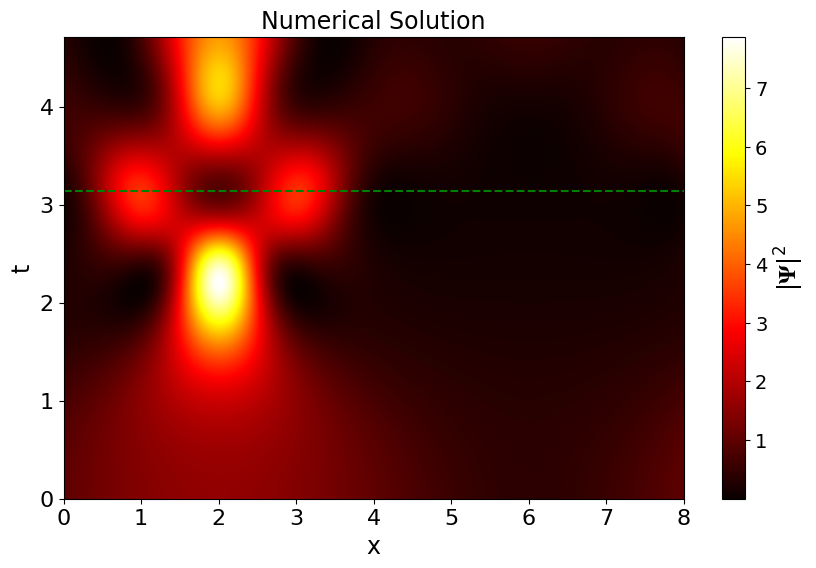

In [17]:
# Define spatial (x) and temporal (t) ranges
# x_min, x_max, x_points = 0.0, 8.0, 1000  # Spatial range and resolution
# t_min, t_max, t_points = 0, 4.0, 1000    # Temporal range and resolution

# # Generate x and t values
# x_vals = torch.linspace(x_min, x_max, x_points).view(-1, 1)  # Shape: (x_points, 1)
# t_vals = torch.linspace(t_min, t_max, t_points).view(-1, 1)  # Shape: (t_points, 1)

# Initialize a 2D array to store density values
density_map = np.zeros((1500,1000))#(t_points, x_points))
t_vals = torch.linspace(0,np.pi/1000*1500,1500).unsqueeze(-1)
x_vals = torch.tensor(x,dtype = rtype).unsqueeze(-1)
# Loop over time steps to compute density
for i, t in enumerate(t_vals):
    t_1 = torch.ones_like(x_vals) * t  # Shape: (x_points, 1)
    xt_1 = torch.cat([x_vals, t_1], dim=1)  # Combine x and t into (x, t) pairs
    
    # Predict density at the current time step
    #psi_collocation_pred = #net(x_vals, t_1)[:, 0:2]  # Assuming net outputs real and imaginary parts
    density_pred = data[i]#get_density(psi_collocation_pred)  # Compute density (shape: (x_points, 1))
    
    # Store density in the 2D array
    density_map[i, :] = density_pred.flatten()

# Plot the density using imshow
plt.figure(figsize=(10, 6))
extent = [x_min, x_max, t_min, t_max]  # Define axis limits for imshow
plt.imshow(density_map, extent=extent, origin='lower', aspect='auto', cmap='hot')
#plt.colorbar(label='Density')
#plt.colorbar(label='$|\U0001D6BF|^2$')#Density',size = 15)
cbar = plt.colorbar(label='$|\U0001D6BF|^2$')
cbar.set_label('$|\U0001D6BF|^2$', fontsize=17)
cbar.ax.tick_params(labelsize=14)  # Adjust tick size here

plt.plot(x_vals, np.pi*torch.ones_like(x_vals), linestyle = '--',color = 'green')
plt.xlabel('x',size = 17)
plt.ylabel('t',size = 17)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
#plt.title('Density Visualization (Predicted by Neural Network)')
plt.title('Numerical Solution',size = 17)
plt.show()

In [86]:
dat1.extend(data)

In [87]:
len(dat1)

101

In [6]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.fft import fftn, ifftn, fftfreq
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, ifft

# Constants and parameters
# hbar = 1.0  # Reduced Planck constant
# G = 1.0     # Gravitational constant
# m_wdm = 1.0 # Mass of wave dark matter particle
# L = 8.0     # Box length
# N = 150     # Number of grid points along each axis
# dx = L / N  # Spatial resolution
# Constants and parameters
hbar = 1.0  # Reduced Planck constant (for simplicity)
G = 1.0     # Gravitational constant (for simplicity)
m_wdm = 1.0#e-7 # Mass of wave dark matter particle
dx = 8./1000.#0.01    # Spatial resolution
dt = np.pi/1500#1/100#np.pi/100#0.04   # Time step
L = 8.0    # Length of the 1D box
N = int(L / dx)  # Number of grid points
x = np.linspace(0,L,N)#np.linspace(-L/2, L/2, N)  # Spatial grid
timesteps = 1500#314#100  # Number of time steps

# Initial conditions for wave dark matter (WDM)
psi = (1.0+0.6*np.sin(2*np.pi * x / L))**0.5 + 1j * np.zeros_like(x)#np.exp(-x**2) + 1j * np.zeros_like(x)  # Initial wave function
rho_wdm = np.abs(psi)**2  #* M_cdm  # CDM mass scaling# Density for WDM


k = 2 * np.pi/L * np.fft.ifftshift(np.arange(-N/2,N/2))

# Poisson solver (1D FFT)
def poisson_solver(rho):
    #k = 2 * np.pi/8.0 * np.fft.fftfreq(N, d=dx)
    rho_k = np.fft.fftn(rho-1.0)
    phi_k = - rho_k / (k**2 + (k==0))  # Small term to avoid division by zero
    phi = np.fft.ifftn(phi_k).real
    return phi


# # Prepare for plotting
# fig, ax = plt.subplots(figsize=(8, 6))
# #im = ax.imshow(np.abs(psi[:, :, N//2])**2, extent=(0, L, 0, L), origin='lower', cmap='viridis')
# plt.colorbar(im, ax=ax, label='Density')
# ax.set_title('Density Evolution (z=L/2)')
# ax.set_xlabel('x')
# ax.set_ylabel('y')
data= []
# Time evolution loop
for t in range(timesteps):
    psi_k = np.fft.fftn(psi)
    #print(psi_k)
    psi_k *= np.exp(-1j * hbar * (k**2) * dt / (2 * m_wdm))
    #print(psi_k)
    psi = np.fft.ifftn(psi_k)
    #print(psi)
    phi_wdm = poisson_solver(np.abs(psi)**2)
    #print(phi_wdm)
    psi *= np.exp(-1j * m_wdm * phi_wdm * dt / hbar)
    #print(np.abs(psi)**2)
    #psi[0] = 1.0+0.0j
    #psi[-1] = 1.0+0.0j
    rho_wdm = np.abs(psi)**2  # Update WDM density
    #print(rho_wdm)

    data.append(np.abs(psi)**2)
    # Update density for visualization
    # if t % 10 == 0:  # Update plot every 10 steps
    #     rho_wdm = np.abs(psi)**2
    #     im.set_data(rho_wdm[:, :, N//2])
    #     plt.pause(0.01)

#plt.show()


In [7]:
len(data)

1500

In [29]:
density_map.shape

(1000, 10000)

In [30]:
data[0]

array([1.00018876, 1.00056112, 1.0009377 , ..., 0.99906293, 0.99943951,
       0.99981187])

In [22]:
data[-1]

array([0.17913171, 0.18016317, 0.18119795, ..., 0.17606499, 0.17708175,
       0.17810414])

In [ ]:
#model = score_model_cond()
#net.load_state_dict(torch.load('PINN2.pt'))
import matplotlib.cm as cm
import matplotlib.colors as mcolors
# Define the time points we want to plot
time_indices = [i / 100 for i in range(0,314, 15)]  # Time points to visualize

# # Set up the figure
# fig = plt.figure(figsize=(10, 6))
# plt.title('Density Predictions at Different Times')
# plt.xlabel('$x$')
# plt.ylabel('$|\psi(x, t)|^2$')

# Use a colormap for the rainbow effect
cmap = plt.cm.rainbow
colors = cmap(np.linspace(0, 1, len(time_indices)))
fig, ax = plt.subplots(figsize = (10,6))

# Loop over selected time points and plot each density profile
for idx, color in zip(time_indices, colors):
    # Update time value for current plot
    t_1 = torch.ones((10000, 1)) * idx
    x_1 = torch.rand((10000, 1)) * (8.0 - 0.0)  # Adjust xl and xr as needed
    xt_1 = torch.cat([x_1, t_1], dim=1)

    # Predict density at the current time
    psi_collocation_pred = net(x_1,t_1)[:,0:2]  # Assuming `model` outputs both real and imag
    density_pred =get_density(psi_collocation_pred)
    #print(len(x_1))
    #print(len(density_pred))
    print(torch.sum(density_pred))
    # Plot the density for the current time
    ax.scatter(
        x_1.detach().numpy(),
        density_pred.detach().numpy(),
        color=color,
        marker='X',
        label=f"$t = {idx:.2f}$"
    )
    #plt.colorbar()
# Add legend and show plot
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# #plt.colorbar()
# plt.tight_layout()
# plt.show()

norm = mcolors.Normalize(vmin=min(time_indices), vmax=max(time_indices))
cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap='rainbow'), ax=ax)
cbar.set_label("Time (t)", rotation=90, labelpad=15,size = 15)

# Add labels and layout adjustments
#ax.set_xlabel("x",size = 15)
#ax.set_ylabel("Density",size = 15)
#ax.set_title('Density Predictions at Different Times')
ax.set_xlabel('$x$',size = 15)
ax.set_ylabel('$|\U0001D6BF|^2$',size = 15)
#ax.set_ylabel('$|\U0001D713|^2$',size = 15)

plt.tight_layout()
plt.show()


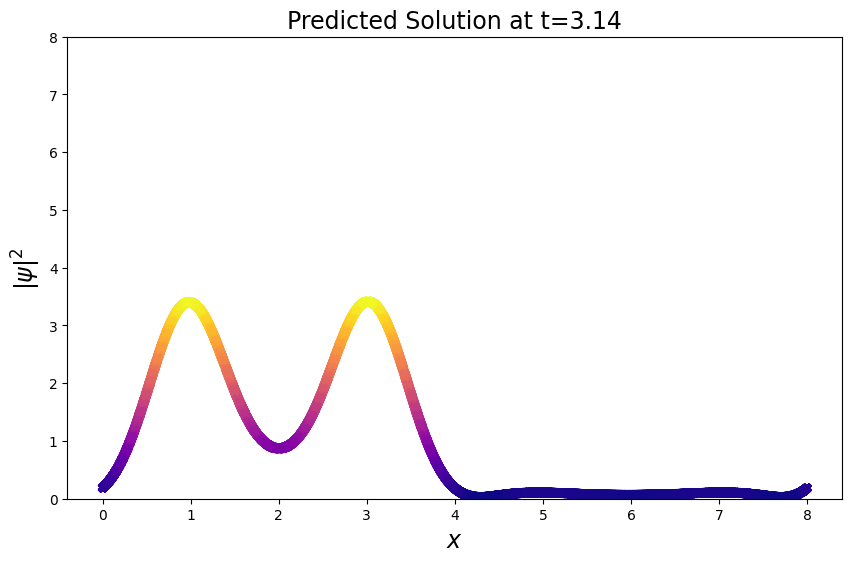

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.animation import FuncAnimation, PillowWriter

# Define the time points
num_frames = 50  # Number of frames in animation
time_indices = np.linspace(0, 3.14, num_frames)  # Adjust based on your range

# Set up the figure
fig, ax = plt.subplots(figsize=(10, 6))
# cmap = cm.rainbow
# norm = mcolors.Normalize(vmin=min(time_indices), vmax=max(time_indices))
# cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap='rainbow'), ax=ax)
# cbar.set_label("Time (t)", rotation=90, labelpad=15, size=17)
# cbar.ax.tick_params(labelsize=14)
ax.set_title('Predicted Solution', size=17)
ax.set_xlabel('$x$', size=17)
ax.set_ylabel('$|\psi|^2$', size=17)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# Set fixed y-axis limits (adjust as needed)
y_min, y_max = 0, 8  # Modify these values based on expected density range
ax.set_ylim(y_min, y_max)
# Initialize the scatter plot
sc = ax.scatter([], [], c=[], cmap='rainbow', marker='X')

# Function to update the animation
def update(frame):
    ax.clear()
    t_val = time_indices[frame]
    t_1 = torch.ones((10000, 1)) * t_val
    x_1 = torch.rand((10000, 1)) * 8.0  # Adjust xl and xr as needed
    
    # Predict density
    psi_collocation_pred = net(x_1, t_1)[:, 0:2]  # Assuming `net` outputs real & imag parts
    density_pred = get_density(psi_collocation_pred)
    density_norm = (density_pred - density_pred.min()) / (density_pred.max() - density_pred.min())

    ax.scatter(
        x_1.detach().numpy(),
        density_pred.detach().numpy(),
        c=density_norm.detach().numpy(),
        cmap='plasma',
        marker='X'
    )
    ax.set_title(f'Predicted Solution at t={t_val:.2f}', size=17)
    ax.set_xlabel('$x$', size=17)
    ax.set_ylabel('$|\psi|^2$', size=17)
    ax.set_ylim(y_min, y_max)  # Keep y-axis limits consistent

# Create the animation
ani = FuncAnimation(fig, update, frames=num_frames, interval=100)

# Save the animation as a GIF
ani.save("density_evolution.gif", writer=PillowWriter(fps=10))

plt.show()

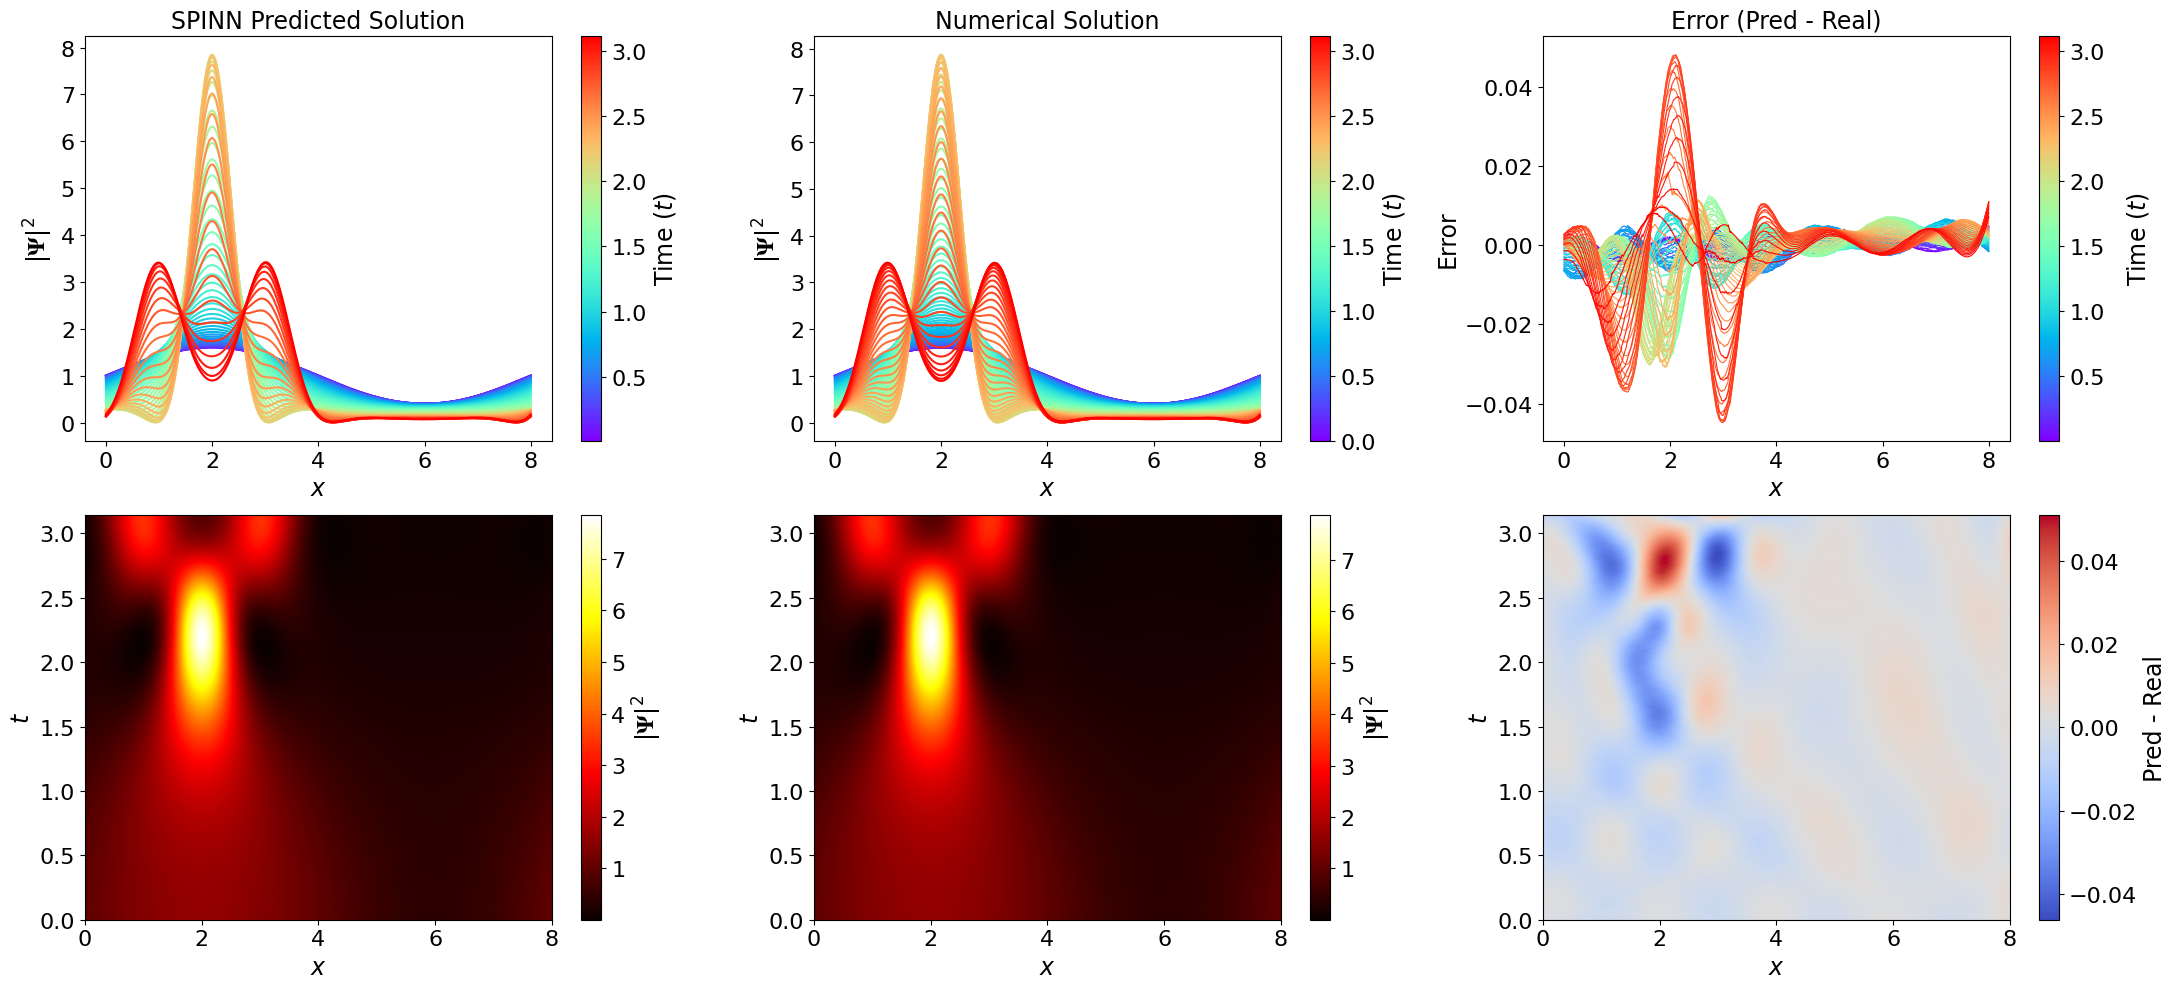

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
time_list = np.arange(0, timesteps * dt, dt)

# Assume: net, get_density, data, x, time_list, dt, timesteps are already defined
x_min, x_max, x_points = 0.0, 8.0, 1000
t_min, t_max, t_points = 0, np.pi, 1500
x_vals = torch.linspace(x_min, x_max, x_points).view(-1, 1)
t_vals = torch.linspace(t_min, t_max, t_points).view(-1, 1)

# === Create 2x3 Subplot Grid ===
fig, ax = plt.subplots(2, 3, figsize=(22, 10))
plt.subplots_adjust(wspace=0.3, hspace=0.3)

# === Define Color Map ===
cmap = plt.cm.rainbow

# ---------------------------------------
# TOP-LEFT: Predicted Line Plots
# ---------------------------------------
time_indices = [i / 100 for i in range(1, 314, 5)]
colors = cmap(np.linspace(0, 1, len(time_indices)))

for idx, color in zip(time_indices, colors):
    t_1 = torch.ones_like(x_vals) * idx
    x_1 = torch.from_numpy(x.reshape((1000, 1)).astype('float32'))
    #psi = net(x_vals, t_1)[:, 0:2]
    psi = net(x_1, t_1)[:, 0:2]
    density = get_density(psi)
    ax[0, 0].plot(x_vals.detach().numpy(), density.detach().numpy(), color=color)

ax[0, 0].set_title("SPINN Predicted Solution", fontsize=17)
ax[0, 0].set_xlabel("$x$", fontsize=17)
ax[0, 0].set_ylabel("$|\U0001D6BF|^2$", fontsize=17)
cbar0 = fig.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=min(time_indices), vmax=max(time_indices)), cmap='rainbow'), ax=ax[0, 0])
cbar0.set_label("Time ($t$)", fontsize=17)
cbar0.ax.tick_params(labelsize=16)

# ---------------------------------------
# TOP-MID: Numerical Scatter Plots
# ---------------------------------------
pt = [i for i in range(0, len(time_list), 15)]
time_indices_data = [time_list[i] for i in pt]
colors_data = cmap(np.linspace(0, 1, len(time_indices_data)))

for i, (idx, color) in enumerate(zip(time_indices_data, colors_data)):
    x_1 = torch.from_numpy(x.reshape((1000, 1)).astype('float32'))
    density_true = data[pt[i]]
    ax[0, 1].plot(x_1.numpy(), density_true, color=color)

ax[0, 1].set_title("Numerical Solution", fontsize=17)
ax[0, 1].set_xlabel("$x$", fontsize=17)
ax[0, 1].set_ylabel("$|\U0001D6BF|^2$", fontsize=17)
cbar1 = fig.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=min(time_indices_data), vmax=max(time_indices_data)), cmap='rainbow'), ax=ax[0, 1])
cbar1.set_label("Time ($t$)", fontsize=17)
cbar1.ax.tick_params(labelsize=16)

# ---------------------------------------
# TOP-RIGHT: Error Line Plots
# ---------------------------------------
# for i, (idx, color) in enumerate(zip(time_indices_data, colors_data)):
#     t_1 = torch.ones_like(x_vals) * idx
#     #psi = net(x_vals, t_1)[:, 0:2]
#     x_1 = torch.from_numpy(x.reshape((1000, 1)).astype('float32'))
#     #psi = net(x_vals, t_1)[:, 0:2]
#     psi = net(x_1, t_1)[:, 0:2]
#     density_pred = get_density(psi).detach().cpu().numpy().flatten()
#     density_true = data[pt[i]]
#     error = (density_pred - density_true)
#     ax[0, 2].plot(x_vals.detach().numpy(), error, color=color)

# ax[0, 2].set_title("Absolute Error (Line)", fontsize=16)
# ax[0, 2].set_xlabel("$x$", fontsize=14)
# ax[0, 2].set_ylabel("Error", fontsize=14)
# cbar2 = fig.colorbar(cm.ScalarMappable(norm=mcolors.Normalize(vmin=min(time_indices_data), vmax=max(time_indices_data)), cmap='rainbow'), ax=ax[0, 2])
# cbar2.set_label("Time $t$", fontsize=14)

# ---------------------------------------
# TOP-RIGHT: Error Line Plot (Custom Code)
# ---------------------------------------
import matplotlib.cm as cm
import matplotlib.colors as mcolors

time_indices = [time_list[i] for i in range(1, 1500, 15)]
pt = [i for i in range(0, len(time_list), 15)]

cmap = plt.cm.rainbow
colors = cmap(np.linspace(0, 1, len(time_indices)))

l = 0
for idx, color in zip(time_indices, colors):
    t_1 = torch.ones((1000, 1)) * idx
    x_1 = torch.from_numpy(x.reshape((1000, 1)).astype('float32'))

    psi_collocation_pred = net(x_1, t_1)[:, 0:2]
    density_pred = get_density(psi_collocation_pred).detach().numpy()
    density_true = data[pt[l]]

    error = density_pred - density_true  # Absolute error

    ax[0, 2].plot(
        x_1.numpy(),
        error,
        color=color,
        linewidth=0.8,
        label=f"$t = {idx:.2f}$"
    )
    l += 1

norm = mcolors.Normalize(vmin=min(time_indices), vmax=max(time_indices))
cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap='rainbow'), ax=ax[0, 2])
cbar.set_label("Time ($t$)", rotation=90, labelpad=15, size=17)
cbar.ax.tick_params(labelsize=16)

ax[0, 2].set_title(r'Error (Pred - Real)', fontsize=17)
ax[0, 2].set_xlabel("$x$", fontsize=17)
ax[0, 2].set_ylabel("Error", fontsize=17)

# ---------------------------------------
# BOTTOM-LEFT: Predicted Heatmap
# ---------------------------------------
density_map_pred = np.zeros((t_points, x_points))
for i, t in enumerate(t_vals):
    t_1 = torch.ones_like(x_vals) * t
    psi_pred = net(x_vals, t_1)[:, 0:2]
    density_pred = get_density(psi_pred)
    density_map_pred[i, :] = density_pred.detach().cpu().numpy().flatten()

im1 = ax[1, 0].imshow(density_map_pred, extent=[x_min, x_max, t_min, t_max], origin='lower', aspect='auto', cmap='hot')
#ax[1, 0].set_title("Predicted Heatmap", fontsize=16)
ax[1, 0].set_xlabel("$x$", fontsize=17)
ax[1, 0].set_ylabel("$t$", fontsize=17)
c0 = fig.colorbar(im1, ax=ax[1, 0])#, label="$|\U0001D6BF|^2$")
c0.set_label("$|\U0001D6BF|^2$", fontsize=17)
c0.ax.tick_params(labelsize=16)
# ---------------------------------------
# BOTTOM-MID: Numerical Heatmap
# ---------------------------------------
density_map_data = np.zeros((t_points, x_points))
for i, t in enumerate(t_vals):
    density_map_data[i, :] = data[i].flatten()

im2 = ax[1, 1].imshow(density_map_data, extent=[x_min, x_max, t_min, t_max], origin='lower', aspect='auto', cmap='hot')
#ax[1, 1].set_title("Numerical Heatmap", fontsize=16)
ax[1, 1].set_xlabel("$x$", fontsize=17)
ax[1, 1].set_ylabel("$t$", fontsize=17)
c1 = fig.colorbar(im2, ax=ax[1, 1])#, label="$|\U0001D6BF|^2$")
c1.set_label("$|\U0001D6BF|^2$", fontsize=17)
c1.ax.tick_params(labelsize=16)
# ---------------------------------------
# BOTTOM-RIGHT: Error Heatmap
# ---------------------------------------
error_map = (density_map_pred - density_map_data)
im3 = ax[1, 2].imshow(error_map, extent=[x_min, x_max, t_min, t_max], origin='lower', aspect='auto', cmap='coolwarm')
#ax[1, 2].set_title("Error", fontsize=16)
ax[1, 2].set_xlabel("$x$", fontsize=17)
ax[1, 2].set_ylabel("$t$", fontsize=17)
c2 = fig.colorbar(im3, ax=ax[1, 2])#, label="|Pred - Data|")
c2.set_label("Pred - Real", fontsize=17)
c2.ax.tick_params(labelsize=16)
# === Final Touches ===
for a in ax.flat:
    a.tick_params(labelsize=16)

plt.tight_layout()
plt.show()
